# NYC Citi Bike Trip Analysis -- January 2024

Dataset: [Citi Bike System Data](https://citibikenyc.com/system-data), published monthly at
https://s3.amazonaws.com/tripdata/index.html. This notebook uses January 2024
(~1.9M trips) as a single, self-contained month -- a simpler dataset than the
full MTA subway feed for practicing the basics: cleaning, EDA, and reading
patterns out of the data.

Goal: understand how members (subscribers) and casual riders use the system
differently -- when they ride, how long for, and where.

In [17]:
import pandas as pd
import numpy as np
import requests
import zipfile
import io
import matplotlib.pyplot as plt
import seaborn as sns

## Load data

In [18]:
url = "https://s3.amazonaws.com/tripdata/202401-citibike-tripdata.zip"

print("Downloading January 2024 Citi Bike trip data...")
resp = requests.get(url)
resp.raise_for_status()

with zipfile.ZipFile(io.BytesIO(resp.content)) as z:
    names = [n for n in z.namelist() if n.endswith(".csv")]
    df = pd.concat(
        [pd.read_csv(z.open(n), dtype={"start_station_id": str, "end_station_id": str}) for n in names],
        ignore_index=True,
    )

print(f"Loaded {len(df):,} rows from {names}")

Loaded 1,888,085 rows from ['202401-citibike-tripdata_2.csv', '202401-citibike-tripdata_1.csv']


In [19]:
df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,62EF1AC5BE598131,classic_bike,2024-01-24 09:03:33.533,2024-01-24 09:06:53.535,E 102 St & 1 Ave,7407.13,E 103 St & Lexington Ave,7463.09,40.786995,-73.941648,40.790305,-73.947558,member
1,8464E543DAB27DBF,classic_bike,2024-01-30 08:21:29.510,2024-01-30 08:29:03.304,E 102 St & 1 Ave,7407.13,E 91 St & 2 Ave,7286.01,40.786995,-73.941648,40.781153,-73.949630,member
2,9C04FDC8549F5205,electric_bike,2024-01-22 21:18:25.199,2024-01-22 21:26:24.647,W 35 St & 8 Ave,6526.01,1 Ave & E 39 St,6303.01,40.752762,-73.992805,40.747140,-73.971130,member
3,7DD1703A3E0D8833,electric_bike,2024-01-31 22:15:49.861,2024-01-31 22:22:45.520,Warren St & Roosevelt Ave,6346.07,112 St & Northern Blvd,6683.01,40.749190,-73.870540,40.757880,-73.857630,member
4,6A96FCD170996E59,classic_bike,2024-01-29 22:52:28.276,2024-01-29 22:57:05.099,6 Ave & W 33 St,6364.07,W 29 St & 9 Ave,6416.06,40.749013,-73.988484,40.750073,-73.998393,member


In [20]:
print(df.dtypes)
print(df.isnull().sum())

ride_id                object
rideable_type          object
started_at             object
ended_at               object
start_station_name     object
start_station_id       object
end_station_name       object
end_station_id         object
start_lat             float64
start_lng             float64
end_lat               float64
end_lng               float64
member_casual          object
dtype: object
ride_id                  0
rideable_type            0
started_at               0
ended_at                 0
start_station_name    1160
start_station_id      1160
end_station_name      5505
end_station_id        5505
start_lat             1160
start_lng             1160
end_lat               5486
end_lng               5486
member_casual            0
dtype: int64


## Clean

In [21]:
df['started_at'] = pd.to_datetime(df['started_at'])
df['ended_at'] = pd.to_datetime(df['ended_at'])
df['trip_minutes'] = (df['ended_at'] - df['started_at']).dt.total_seconds() / 60

before = len(df)

# exact duplicate trips
df = df.drop_duplicates(subset='ride_id')

# a handful of trips spill over from December / into February at the file's
# edges -- keep the file to the month it claims to cover
df = df[(df['started_at'] >= '2024-01-01') & (df['started_at'] < '2024-02-01')]

# trips missing station info or coordinates aren't usable for station/geo analysis
df = df.dropna(subset=['start_station_name', 'end_station_name', 'start_lat', 'start_lng', 'end_lat', 'end_lng'])

# a trip can't have zero/negative duration
df = df[df['trip_minutes'] > 0]

# Citi Bike's own policy treats checkouts over 24h as a lost/stolen bike
# report, not a real ride -- these are an operational anomaly, not signal
df = df[df['trip_minutes'] <= 24 * 60]

after = len(df)
print(f"Removed {before - after:,} rows ({(before - after) / before:.2%})")
print(f"Remaining: {after:,}")

Removed 6,498 rows (0.34%)
Remaining: 1,881,587


In [22]:
df['trip_minutes'].describe()

count    1.881587e+06
mean     1.081312e+01
std      1.981575e+01
min      1.000733e+00
25%      4.660133e+00
50%      7.720200e+00
75%      1.292958e+01
max      1.439537e+03
Name: trip_minutes, dtype: float64

## Exploratory Data Analysis

A few cuts of the cleaned data to see how members and casual riders differ.

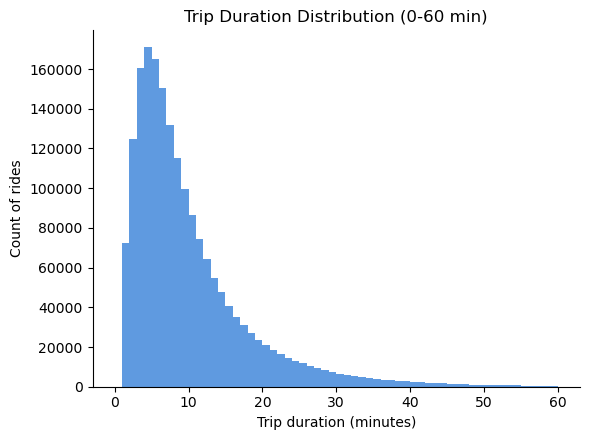

In [23]:
# trip duration distribution
plt.figure(figsize=(6, 4.5))
sns.histplot(df['trip_minutes'], bins=60, binrange=(0, 60), color="#2a78d6", edgecolor="none")
plt.title("Trip Duration Distribution (0-60 min)")
plt.xlabel("Trip duration (minutes)")
plt.ylabel("Count of rides")
sns.despine()
plt.tight_layout()
plt.show()
# right-skewed as expected: most rides are quick point-to-point trips, with a
# long tail of longer leisure rides

In [24]:
# rider mix
print("Member vs casual:\n", df['member_casual'].value_counts(normalize=True))
print("\nBike type:\n", df['rideable_type'].value_counts(normalize=True))

Member vs casual:
 member_casual
member    0.890232
casual    0.109768
Name: proportion, dtype: float64

Bike type:
 rideable_type
electric_bike    0.642355
classic_bike     0.357645
Name: proportion, dtype: float64


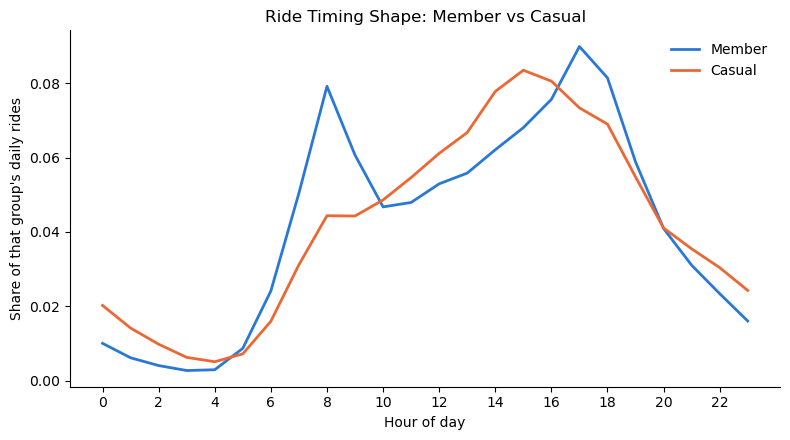

In [25]:
# ride timing shape: member vs casual, each normalized to its own daily total
# so the shapes are comparable despite members outnumbering casual riders ~8:1
rider_colors = {"member": "#2a78d6", "casual": "#eb6834"}

df['hour'] = df['started_at'].dt.hour
hourly = df.groupby(['hour', 'member_casual']).size().unstack()
hourly_share = hourly.div(hourly.sum(axis=0), axis=1)

plt.figure(figsize=(8, 4.5))
plt.plot(hourly_share.index, hourly_share['member'], color=rider_colors['member'], linewidth=2, label='Member')
plt.plot(hourly_share.index, hourly_share['casual'], color=rider_colors['casual'], linewidth=2, label='Casual')
plt.title("Ride Timing Shape: Member vs Casual")
plt.xlabel("Hour of day")
plt.ylabel("Share of that group's daily rides")
plt.xticks(range(0, 24, 2))
plt.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.show()
# members show the classic AM/PM commute double-peak (8am, 5-6pm); casual
# riders build gradually to one broad afternoon peak instead -- members are
# commuters, casual riders are closer to leisure/tourist use

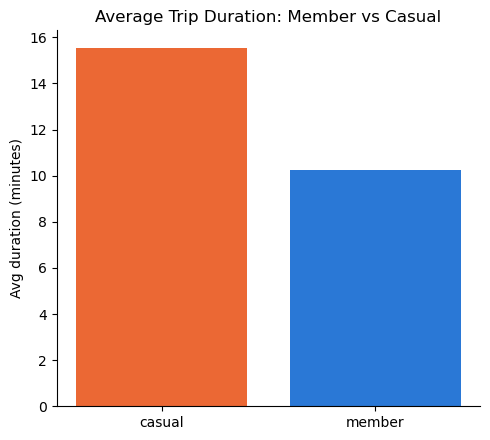

member_casual
casual    15.526833
member    10.231908
Name: trip_minutes, dtype: float64


In [26]:
# average trip duration: member vs casual
avg_duration = df.groupby('member_casual')['trip_minutes'].mean()

plt.figure(figsize=(5, 4.5))
plt.bar(avg_duration.index, avg_duration.values, color=[rider_colors[m] for m in avg_duration.index])
plt.title("Average Trip Duration: Member vs Casual")
plt.ylabel("Avg duration (minutes)")
sns.despine()
plt.tight_layout()
plt.show()
print(avg_duration)
# casual riders take trips about 50% longer on average -- consistent with
# leisure riding rather than point-to-point commuting

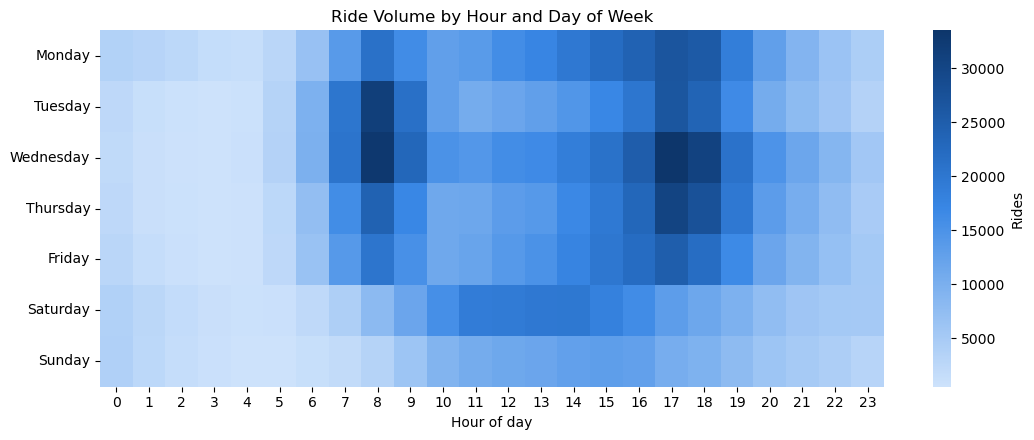

In [27]:
# ride volume heatmap: hour of day x day of week
from matplotlib.colors import LinearSegmentedColormap

blue_seq = LinearSegmentedColormap.from_list(
    "blue_seq", ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
)

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['day'] = df['started_at'].dt.day_name()
heat = df.groupby(['day', 'hour']).size().unstack().reindex(day_order)

plt.figure(figsize=(11, 4.5))
sns.heatmap(heat, cmap=blue_seq, cbar_kws={"label": "Rides"})
plt.title("Ride Volume by Hour and Day of Week")
plt.xlabel("Hour of day")
plt.ylabel("")
plt.tight_layout()
plt.show()
# sharp weekday rush-hour columns at 8am and 5-6pm; weekends spread ridership
# across a broader, later midday window

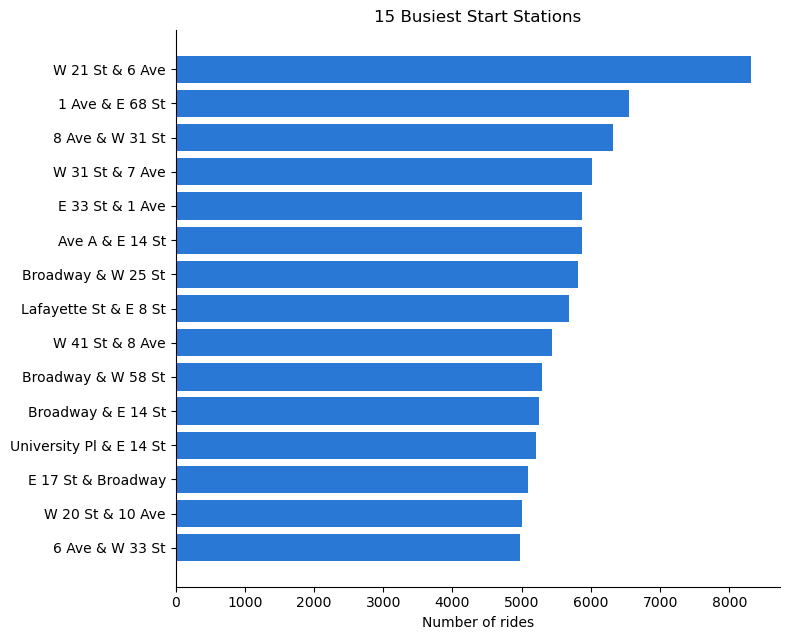

In [28]:
# 15 busiest start stations
top_stations = df['start_station_name'].value_counts().head(15)

plt.figure(figsize=(8, 6.5))
plt.barh(top_stations.index[::-1], top_stations.values[::-1], color="#2a78d6")
plt.title("15 Busiest Start Stations", fontsize=12)
plt.xlabel("Number of rides")
sns.despine()
plt.tight_layout()
plt.show()